# Exploratory Data Analysis — SECOM Manufacturing Dataset

**Explainable AI-Based Predictive Maintenance System**

This notebook explores the raw SECOM dataset before any modeling decisions are made:
dataset shape, target balance, missing values, feature variance, correlation structure, and
which features look most associated with the failure label. Every number and plot below is
computed from the actual dataset — nothing here is fabricated.

All loading and diagnostic logic is imported from `src/`, so this notebook and the training
pipeline (`train_pipeline.py`) always agree on how the data is read and described.


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.data_loader import analyze_dataset, get_feature_columns, load_secom_dataset
from src.train import make_train_test_split
from src.utils import CONFIG, TARGET_COLUMN, set_global_seed

set_global_seed(CONFIG.random_seed)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 20)


## 1. Load the Dataset

In [2]:
df = load_secom_dataset()
print(f"Shape: {df.shape}")
df.head()

2026-08-18 22:43:04 | INFO     | src.data_loader | Loaded SECOM dataset: 1567 rows x 590 raw features, 104 failures (6.64%).


Shape: (1567, 592)


,Feature_0,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,...,Feature_582,Feature_583,Feature_584,Feature_585,Feature_586,Feature_587,Feature_588,Feature_589,Timestamp,Failure
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,...,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,2008-07-19 11:55:00,0
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,...,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,2008-07-19 12:32:00,0
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,...,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,2008-07-19 13:17:00,1
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,...,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,2008-07-19 14:43:00,0
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031,...,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,2008-07-19 15:22:00,0


## 2. Dataset Diagnostics

`analyze_dataset` is the same function `train_pipeline.py` uses to justify its preprocessing
thresholds (Phase 1) — no separate, possibly-inconsistent logic here.

In [3]:
diagnostics = analyze_dataset(df, missing_threshold=CONFIG.missingness_drop_threshold)
print(diagnostics.summary_text())

2026-08-18 22:43:04 | INFO     | src.data_loader | Dataset diagnostics:
Rows: 1567
Raw features: 590
Class counts (0=normal, 1=failure): {'normal_0': 1463, 'failure_1': 104}
Failure rate: 6.64%
Imbalance ratio (normal:failure): 14.1 : 1
Duplicate rows: 0
Missing cells: 41951 (4.54% of all cells)
Columns with >=1 missing value: 538
Columns with missing rate > 55%: 24
Constant (zero-variance) columns: 116
Near-zero-variance columns (<=1% unique values): 8


Rows: 1567
Raw features: 590
Class counts (0=normal, 1=failure): {'normal_0': 1463, 'failure_1': 104}
Failure rate: 6.64%
Imbalance ratio (normal:failure): 14.1 : 1
Duplicate rows: 0
Missing cells: 41951 (4.54% of all cells)
Columns with >=1 missing value: 538
Columns with missing rate > 55%: 24
Constant (zero-variance) columns: 116
Near-zero-variance columns (<=1% unique values): 8


**Reading these numbers:**

- **~6.6% failure rate** — a ~14:1 class imbalance. Accuracy alone would be a misleading metric
  (predicting "no failure" for every example already scores ~93%).
- **~4.5% of all cells are missing**, but concentrated unevenly: a handful of sensors are missing
  in the large majority of rows, while most sensors have few or no missing values.
- **116 constant columns** carry zero information and zero explanatory value — dropped outright.
- **No duplicate rows.**


## 3. Target Class Distribution (Class Imbalance)

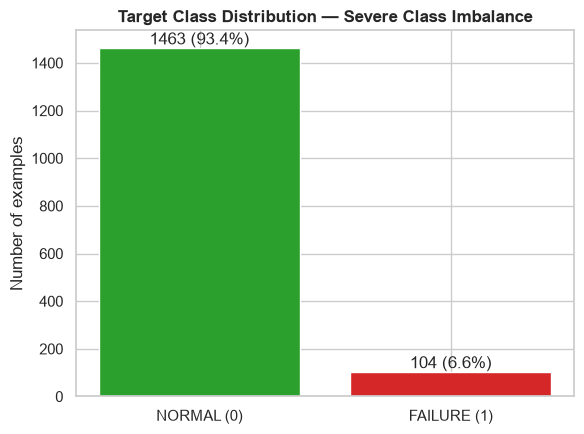

In [4]:
counts = df[TARGET_COLUMN].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(6, 4.5))
bars = ax.bar(["NORMAL (0)", "FAILURE (1)"], counts.values, color=["#2ca02c", "#d62728"])
for bar, count in zip(bars, counts.values):
    pct = 100 * count / len(df)
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{count} ({pct:.1f}%)",
            ha="center", va="bottom")
ax.set_ylabel("Number of examples")
ax.set_title("Target Class Distribution — Severe Class Imbalance", fontweight="bold")
plt.tight_layout()
plt.show()

This confirms the dataset requires explicit imbalance handling (Phase 5 of the training
pipeline compares class-weighting, SMOTE, and SMOTEENN empirically rather than assuming one) and
evaluation metrics beyond accuracy (precision, recall, F1, PR-AUC).

## 4. Missing-Value Analysis

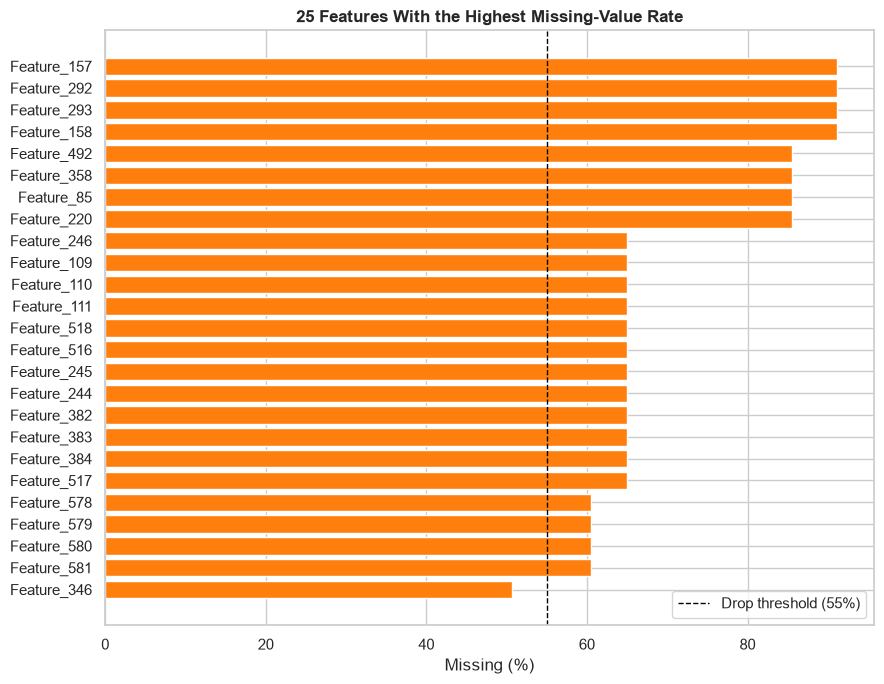

Columns above the 55% drop threshold: 24
Columns with zero missing values: 52


In [5]:
feature_cols = get_feature_columns(df)
missing_rate = 100 * df[feature_cols].isna().mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 7))
top25 = missing_rate.head(25)
ax.barh(top25.index[::-1], top25.values[::-1], color="#ff7f0e")
ax.axvline(100 * CONFIG.missingness_drop_threshold, color="black", linestyle="--", linewidth=1,
           label=f"Drop threshold ({CONFIG.missingness_drop_threshold:.0%})")
ax.set_xlabel("Missing (%)")
ax.set_title("25 Features With the Highest Missing-Value Rate", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Columns above the {CONFIG.missingness_drop_threshold:.0%} drop threshold: "
      f"{(missing_rate > 100*CONFIG.missingness_drop_threshold).sum()}")
print(f"Columns with zero missing values: {(missing_rate == 0).sum()}")

**Preprocessing decision:** columns missing in more than 55% of rows are dropped outright
(`src/preprocessing.py: HighMissingnessDropper`) rather than imputed — at that level of
missingness, median-imputing would mostly be injecting a constant into the model. Everything
below the threshold is median-imputed, which is robust to the skew typical of raw sensor data.

## 5. Train/Test Split (for all further leakage-sensitive analysis)

In [6]:
X_train, X_test, y_train, y_test = make_train_test_split(df, test_size=CONFIG.test_size,
                                                          random_state=CONFIG.random_seed)
print(f"Train: {X_train.shape}, failure rate = {y_train.mean():.2%}")
print(f"Test:  {X_test.shape}, failure rate = {y_test.mean():.2%}")

2026-08-18 22:43:04 | INFO     | src.train | Train/test split: 1253 train (6.62% failures), 314 test (6.69% failures).


Train: (1253, 590), failure rate = 6.62%
Test:  (314, 590), failure rate = 6.69%


From this point on, every statistic is computed on the **training split only** — the same
discipline the modeling pipeline follows — so nothing here would leak test-set information into a
modeling decision.

## 6. Feature Variance Distribution

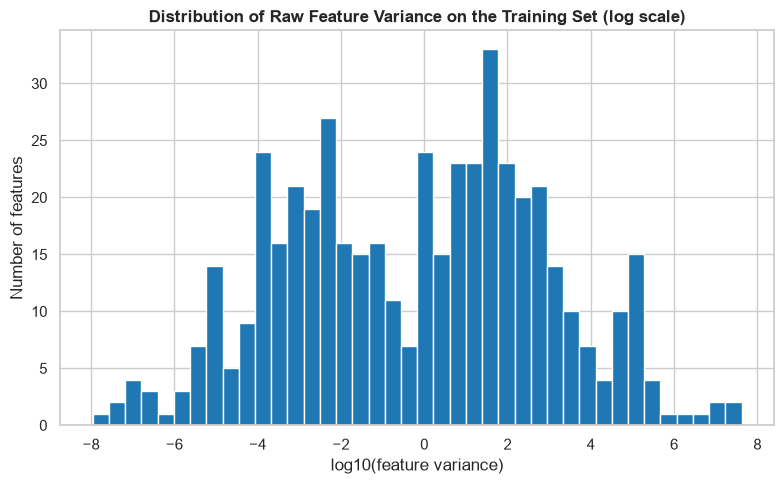

Zero-variance (constant) columns in the training split: 116


In [7]:
variances = X_train[feature_cols].var(numeric_only=True).dropna()
variances_positive = variances[variances > 0]

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(np.log10(variances_positive.values), bins=40, color="#1f77b4")
ax.set_xlabel("log10(feature variance)")
ax.set_ylabel("Number of features")
ax.set_title("Distribution of Raw Feature Variance on the Training Set (log scale)", fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Zero-variance (constant) columns in the training split: {(variances == 0).sum()}")

## 7. Correlation Structure (Highest-Variance Features)

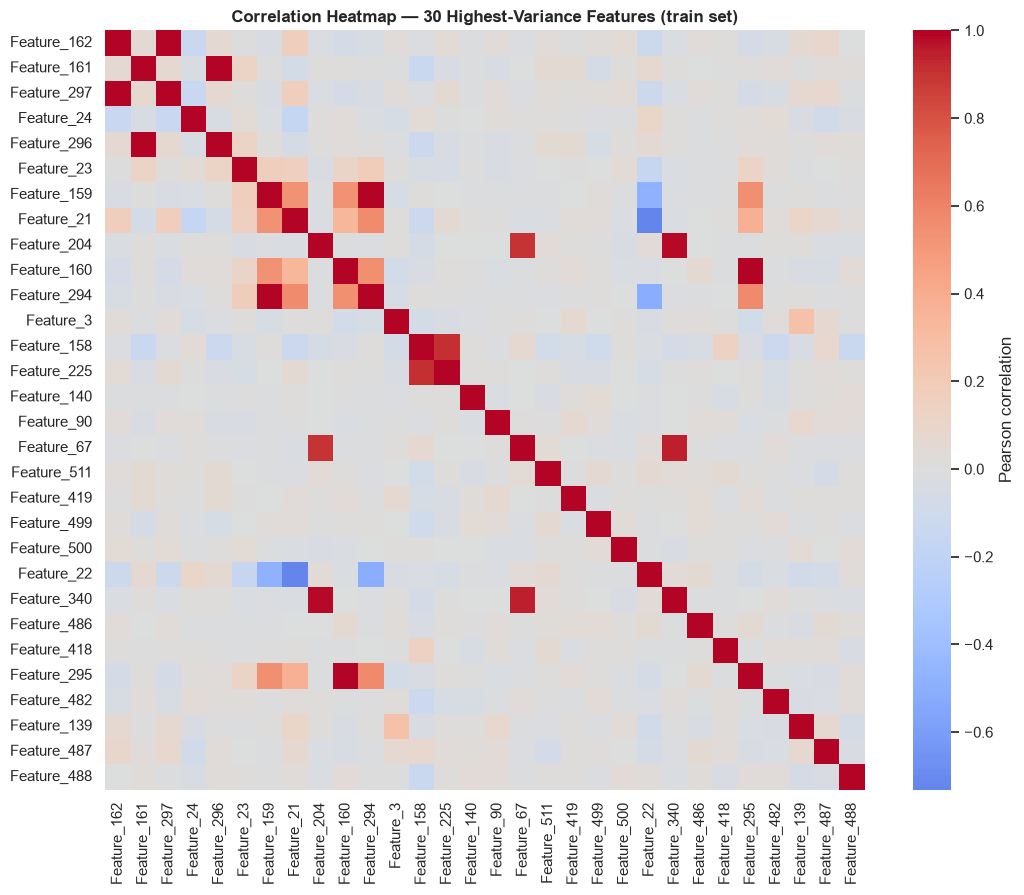

In [8]:
top_var_cols = X_train.var(numeric_only=True).sort_values(ascending=False).head(30).index
corr = X_train[top_var_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True, ax=ax, cbar_kws={"label": "Pearson correlation"})
ax.set_title("Correlation Heatmap — 30 Highest-Variance Features (train set)", fontweight="bold")
plt.tight_layout()
plt.show()

Several tight clusters of near-perfectly correlated sensors are visible — physically
plausible for a manufacturing line, where multiple sensors often track the same underlying
process step. This motivates the correlation-filtering step in `src/feature_selection.py`
(drop one of any pair correlated above 0.95) before ranking by mutual information.

## 8. Features Most Associated With Failure

In [9]:
imputed = X_train[feature_cols].fillna(X_train[feature_cols].median())
corr_with_target = imputed.corrwith(y_train).abs().sort_values(ascending=False)
top_features = corr_with_target.head(6).index.tolist()
print("Top 6 features by |correlation| with the failure label:")
print(corr_with_target.head(10))

Top 6 features by |correlation| with the failure label:
Feature_103    0.172453
Feature_510    0.143783
Feature_59     0.125891
Feature_348    0.111400
Feature_129    0.107639
Feature_431    0.105535
Feature_64     0.103988
Feature_21     0.099321
Feature_125    0.094642
Feature_430    0.092835
dtype: float64


/Users/aniket/Documents/GitHub/xai-predictive-maintenance/.venv/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/aniket/Documents/GitHub/xai-predictive-maintenance/.venv/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


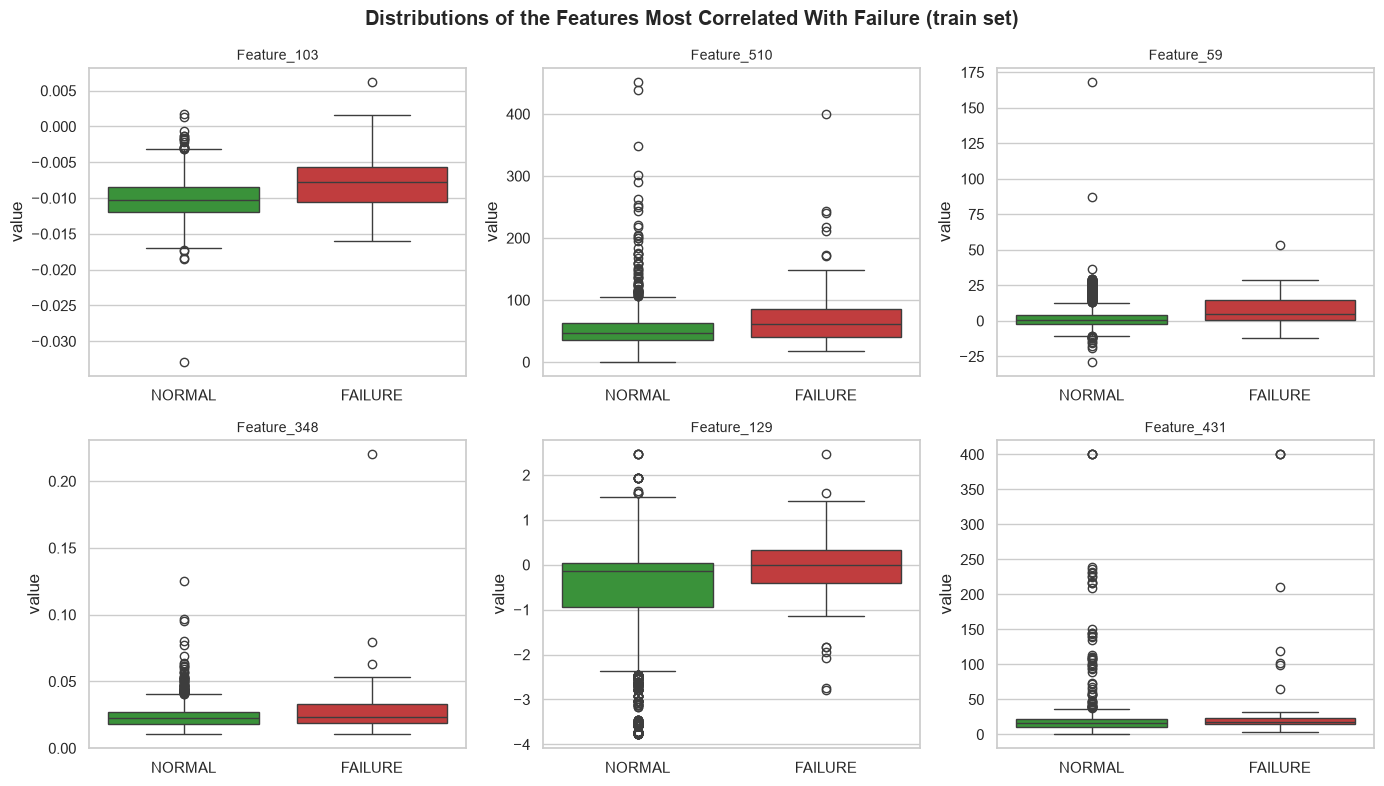

In [10]:
plot_df = imputed[top_features].copy()
plot_df[TARGET_COLUMN] = y_train.map({0: "NORMAL", 1: "FAILURE"}).values
melted = plot_df.melt(id_vars=TARGET_COLUMN, var_name="feature", value_name="value")

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, feature in zip(axes.flat, top_features):
    sns.boxplot(data=melted[melted["feature"] == feature], x=TARGET_COLUMN, y="value", hue=TARGET_COLUMN,
                palette={"NORMAL": "#2ca02c", "FAILURE": "#d62728"}, ax=ax, legend=False)
    ax.set_title(feature, fontsize=10)
    ax.set_xlabel("")
fig.suptitle("Distributions of the Features Most Correlated With Failure (train set)", fontweight="bold")
plt.tight_layout()
plt.show()

These boxplots also double as an outlier check: several features show a handful of points
well beyond the whiskers for both classes — consistent with the noisy, real-world sensor data
SECOM is known for, and part of why `DiCEExplainer` bounds counterfactual suggestions to the
1st-99th percentile of observed values rather than raw min/max (see `src/explain_dice.py`).

A simple pairwise correlation with the label is a *linear, univariate* signal only — it is not
the feature-selection method actually used for modeling (`src/feature_selection.py` uses
mutual information, which also captures non-linear relationships), but it is a useful,
leakage-safe sanity check that at least some individual sensors carry real signal.

## 9. Summary

- SECOM is small (1,567 rows) relative to its dimensionality (590 raw features), severely
  imbalanced (~6.6% failures), and has structured missingness and heavy feature redundancy.
- These characteristics directly motivate every major preprocessing decision made in
  `src/preprocessing.py` and `src/feature_selection.py`, and the explicit imbalance-strategy
  comparison in `train_pipeline.py` (Phase 5) rather than assuming SMOTE upfront.
- See `train_pipeline.py` for the full modeling pipeline, and `outputs/metrics/` /
  `outputs/figures/` for the actual trained-model results this EDA feeds into.
